# Chapter 8 - Linear Regression: From Description to Estimate
### Companion Notebook

*Data Science for Business and Economics: A Python Approach* - Dr. Jorge Zazueta Gutierrez

This notebook mirrors every code example in Chapter 8. Every cell is deterministic:
the dataset is fixed, and the numbers printed here match the numbers in the chapter
exactly.

The data file `meridian_po_lines.csv` must sit alongside this notebook. In Colab,
upload it with the file browser in the left sidebar before running the cells below.

In [1]:
book_metadata = {
    "title": "Data Science for Business and Economics: A Python Approach",
    "chapter": 8,
    "chapter_title": "Linear Regression: From Description to Estimate",
    "author": "Jorge Zazueta Gutierrez",
    "protagonist": "Daniel Okafor",
    "part": 2,
    "part_title": "Methods and Models",
}
book_metadata

{'title': 'Data Science for Business and Economics: A Python Approach',
 'chapter': 8,
 'chapter_title': 'Linear Regression: From Description to Estimate',
 'author': 'Jorge Zazueta Gutierrez',
 'protagonist': 'Daniel Okafor',
 'part': 2,
 'part_title': 'Methods and Models'}

## 8.1 From Association to Estimate

Daniel Okafor's purchase-order extract covers Meridian Components'
third quarter: eight thousand order lines, each recording what was bought, from whom,
in what quantity and at what unit price.

In [2]:
import pandas as pd
import numpy as np

po = pd.read_csv("meridian_po_lines.csv", parse_dates=["order_date"])
print(po.shape)
print(po["vendor"].value_counts())

(8000, 10)
vendor
Alpha Fasteners Inc.           2075
Britewire Ltd.                 2045
Nordic Steel Co.               1169
Perez Castings S.A.             777
Rhein Polymer GmbH              762
Kwan Precision Ltd.             727
Sato Industrial K.K.            289
Meridian Tooling (internal)     156
Name: count, dtype: int64


Meridian Tooling is a subsidiary. Its prices are internal transfer
prices rather than negotiated ones, so those lines answer a different question than the
rest and are removed before anything is estimated.

In [3]:
lines = po[po["vendor"] != "Meridian Tooling (internal)"].copy()
print(len(po) - len(lines), "internal lines removed;", len(lines), "remain")

156 internal lines removed; 7844 remain


## 8.2 Fitting and Reading a Single Slope

A first fit, in the original units of price and quantity.

In [4]:
import statsmodels.formula.api as smf

fit_levels = smf.ols("unit_price ~ quantity", data=lines).fit()
print(fit_levels.summary().tables[1])
print(round(fit_levels.rsquared, 4))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7435      0.150     51.693      0.000       7.450       8.037
quantity       0.0078      0.000     32.246      0.000       0.007       0.008
0.1171


The slope says larger orders cost more per unit, which contradicts
both procurement theory and Meridian's own contracts. Before taking that up, check the
shape of the two variables.

In [5]:
print(lines[["quantity", "unit_price"]].skew().round(2))

quantity      12.13
unit_price     2.09
dtype: float64


In [6]:
lines["log_price"] = np.log(lines["unit_price"])
lines["log_qty"] = np.log(lines["quantity"])

fit_log = smf.ols("log_price ~ log_qty", data=lines).fit()
print(fit_log.summary().tables[1])
print(round(fit_log.rsquared, 4))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3045      0.037     -8.124      0.000      -0.378      -0.231
log_qty        0.4171      0.008     53.058      0.000       0.402       0.433
0.2642


**Check for yourself.** In simple regression the slope equals
`r * (s_y / s_x)` and R-squared equals the square of the correlation. Both identities
hold exactly here.

In [7]:
r = lines["log_qty"].corr(lines["log_price"])
print(round(r * lines["log_price"].std() / lines["log_qty"].std(), 4))
print(round(r ** 2, 4))

0.4171
0.2642


## 8.3 Controlling for What Else Is Going On

Part class drives both price level and typical order size. Adding it
is what reverses the sign.

In [8]:
fit_class = smf.ols("log_price ~ log_qty + C(part_class)", data=lines).fit()

print(pd.DataFrame({"coef": fit_class.params.round(4),
                    "std err": fit_class.bse.round(4),
                    "t": fit_class.tvalues.round(1)}))
print(round(fit_class.rsquared, 4))

                                       coef  std err      t
Intercept                            3.2809   0.0190  172.5
C(part_class)[T.Fastener]           -2.0563   0.0107 -192.0
C(part_class)[T.Formed Wire]        -1.3188   0.0100 -131.5
C(part_class)[T.Precision Assembly]  1.4308   0.0117  122.3
log_qty                             -0.1793   0.0034  -53.5
0.9271


**The decomposition.** The naive slope equals the controlled slope
plus a bias term: the omitted variable's contribution to price, regressed on the
predictor that was included. It closes exactly.

In [9]:
class_effect = fit_class.params["Intercept"] + sum(
    fit_class.params[f"C(part_class)[T.{c}]"] * (lines["part_class"] == c)
    for c in ["Fastener", "Formed Wire", "Precision Assembly"])

delta = smf.ols("effect ~ log_qty",
                data=lines.assign(effect=class_effect)).fit().params["log_qty"]

print(round(fit_class.params["log_qty"], 4), round(delta, 4),
      round(fit_class.params["log_qty"] + delta, 4))
print(round(fit_log.params["log_qty"], 4))

-0.1793 0.5964 0.4171
0.4171


In [10]:
full = smf.ols("log_price ~ log_qty + C(part_class) + C(vendor)"
                " + lead_time_days + C(contract_type)", data=lines).fit()

print(round(full.params["log_qty"], 4), round(full.bse["log_qty"], 4))
print(round(full.rsquared, 4))

-0.1783 0.0032
0.9322


## 8.4 Categorical Predictors and the Baseline Category

In [11]:
print(pd.get_dummies(lines["part_class"], drop_first=True).head(3).astype(int))

   Fastener  Formed Wire  Precision Assembly
0         0            1                   0
1         0            1                   0
2         0            1                   0


Ordering the category levels moves the baseline. Every class
coefficient changes; the model does not.

In [12]:
lines["part_class"] = pd.Categorical(
    lines["part_class"],
    categories=["Fastener", "Formed Wire", "Cast Housing", "Precision Assembly"])

fit_alt = smf.ols("log_price ~ log_qty + C(part_class)", data=lines).fit()
print(fit_alt.params.round(4))
print(round(fit_alt.rsquared, 4))

Intercept                              1.2246
C(part_class)[T.Formed Wire]           0.7376
C(part_class)[T.Cast Housing]          2.0563
C(part_class)[T.Precision Assembly]    3.4871
log_qty                               -0.1793
dtype: float64
0.9271


In [13]:
print(float(np.abs(fit_class.fittedvalues - fit_alt.fittedvalues).max()))

4.418687638008123e-14


In [14]:
terms = full.params.index.str.contains("vendor|contract|lead")

print(pd.DataFrame({"coef": full.params.round(4),
                    "std err": full.bse.round(4),
                    "pct": (100 * (np.exp(full.params) - 1)).round(1)})[terms])

                                     coef  std err   pct
C(vendor)[T.Britewire Ltd.]       -0.0320   0.0090  -3.1
C(vendor)[T.Kwan Precision Ltd.]   0.1603   0.0229  17.4
C(vendor)[T.Nordic Steel Co.]      0.0895   0.0140   9.4
C(vendor)[T.Perez Castings S.A.]   0.0207   0.0226   2.1
C(vendor)[T.Rhein Polymer GmbH]    0.1354   0.0228  14.5
C(vendor)[T.Sato Industrial K.K.]  0.2077   0.0289  23.1
C(contract_type)[T.Spot buy]       0.1221   0.0069  13.0
lead_time_days                    -0.0031   0.0004  -0.3


Which of those premia does the data actually support? A
cross-tabulation answers it.

In [15]:
print(pd.crosstab(lines["vendor"], lines["part_class"]))

part_class            Fastener  Formed Wire  Cast Housing  Precision Assembly
vendor                                                                       
Alpha Fasteners Inc.      1367          708             0                   0
Britewire Ltd.            1349          696             0                   0
Kwan Precision Ltd.          0            0           447                 280
Nordic Steel Co.             0          723           446                   0
Perez Castings S.A.          0            0           510                 267
Rhein Polymer GmbH           0            0           460                 302
Sato Industrial K.K.         0            0             0                 289


## 8.5 Functional Form and Interactions

In [16]:
inter = smf.ols("log_price ~ log_qty * C(part_class) + C(vendor)"
                 " + lead_time_days + C(contract_type)", data=lines).fit()

slopes = inter.params.index.str.contains("log_qty")
print(pd.DataFrame({"coef": inter.params.round(4),
                    "std err": inter.bse.round(4),
                    "t": inter.tvalues.round(1)})[slopes])
print(round(inter.rsquared, 4))

                                               coef  std err     t
log_qty                                     -0.2407   0.0054 -44.5
log_qty:C(part_class)[T.Formed Wire]         0.0380   0.0082   4.6
log_qty:C(part_class)[T.Cast Housing]        0.1127   0.0083  13.6
log_qty:C(part_class)[T.Precision Assembly]  0.1702   0.0100  17.0
0.9353


The four class elasticities, and what each implies for doubling an
order.

In [17]:
base = inter.params["log_qty"]
for c in ["Fastener", "Formed Wire", "Cast Housing", "Precision Assembly"]:
    key = f"log_qty:C(part_class)[T.{c}]"
    slope = base + inter.params.get(key, 0.0)
    print(f"{c:<20} {slope:+.3f}   doubling: {100 * (2 ** slope - 1):+.1f}%")

Fastener             -0.241   doubling: -15.4%
Formed Wire          -0.203   doubling: -13.1%
Cast Housing         -0.128   doubling: -8.5%
Precision Assembly   -0.070   doubling: -4.8%


In [18]:
f_stat, p_value, df = inter.compare_f_test(full)
print(round(f_stat, 1), df, f"{p_value:.2e}")

125.2 3.0 3.22e-79


Testing the additivity assumption where the data can actually test
it: the three suppliers who quote both cast housings and precision assemblies.

In [19]:
overlap = lines[lines["vendor"].isin(["Kwan Precision Ltd.",
                                      "Perez Castings S.A.",
                                      "Rhein Polymer GmbH"])].copy()
overlap["part_class"] = overlap["part_class"].cat.remove_unused_categories()

additive = smf.ols("log_price ~ log_qty + C(part_class) + C(vendor)", data=overlap).fit()
crossed  = smf.ols("log_price ~ log_qty + C(part_class) * C(vendor)", data=overlap).fit()
print(len(overlap), round(crossed.compare_f_test(additive)[0], 2),
      round(crossed.compare_f_test(additive)[1], 3))

2266 0.56 0.573


## 8.6 Diagnostics and the Limits of the Estimate

In [20]:
lines["resid"] = inter.resid
lines["qtile"] = pd.qcut(lines["quantity"], 4,
                         labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"])

print(lines.groupby("qtile", observed=True)["resid"].std().round(3))

qtile
Q1 smallest    0.352
Q2             0.290
Q3             0.248
Q4 largest     0.224
Name: resid, dtype: float64


**Figure 8.1.** Residual spread against order size. The funnel is the
heteroskedasticity the quartile table reports.

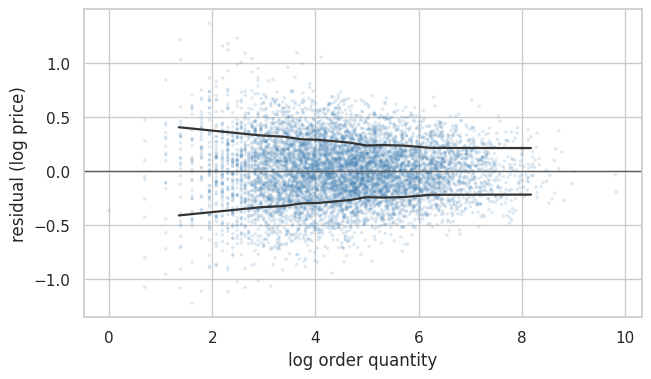

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

STEEL = "#4682B4"
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.scatter(lines["log_qty"], lines["resid"], s=6, alpha=0.18,
           color=STEEL, edgecolors="none")
ax.axhline(0, color="0.35", lw=1)

edges = np.quantile(lines["log_qty"], np.linspace(0, 1, 13))
mids = 0.5 * (edges[:-1] + edges[1:])
sd = [lines.loc[(lines.log_qty >= a) & (lines.log_qty < b), "resid"].std()
      for a, b in zip(edges[:-1], edges[1:])]
ax.plot(mids, sd, color="0.2", lw=1.6)
ax.plot(mids, -np.array(sd), color="0.2", lw=1.6)

ax.set_xlabel("log order quantity")
ax.set_ylabel("residual (log price)")
plt.show()

In [22]:
robust = inter.get_robustcov_results(cov_type="HC3")

i = list(inter.params.index).index("log_qty")
print(round(inter.bse["log_qty"], 4), round(robust.bse[i], 4))

0.0054 0.0064


**Figure 8.2.** Leverage against Cook's distance. Several hundred
lines exceed the conventional threshold; none carries enough influence to matter.

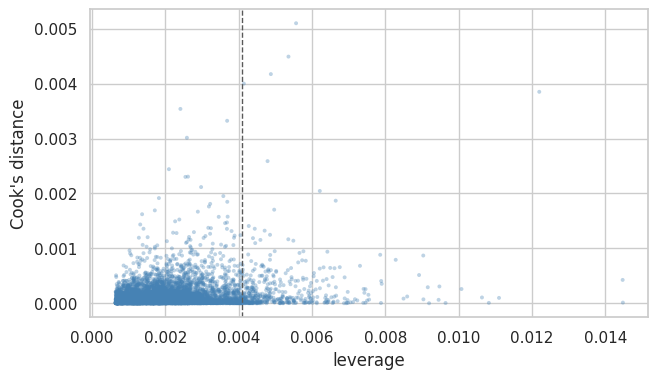

7844 16 0.0041 443 0.0051


In [23]:
infl = inter.get_influence()
h, cooks = infl.hat_matrix_diag, infl.cooks_distance[0]
p, n = len(inter.params), len(lines)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.scatter(h, cooks, s=8, alpha=0.35, color=STEEL, edgecolors="none")
ax.axvline(2 * p / n, color="0.35", lw=1, ls="--")
ax.set_xlabel("leverage")
ax.set_ylabel("Cook's distance")
plt.show()

print(n, p, round(2 * p / n, 4), int((h > 2 * p / n).sum()), round(cooks.max(), 4))

In [24]:
h = inter.get_influence().hat_matrix_diag
trimmed = lines.assign(leverage=h).nsmallest(len(lines) - 20, "leverage")

refit = smf.ols("log_price ~ log_qty * C(part_class) + C(vendor)"
                " + lead_time_days + C(contract_type)", data=trimmed).fit()
print(round(inter.params["log_qty"], 4), round(refit.params["log_qty"], 4))

-0.2407 -0.2407


In [25]:
lad = smf.quantreg("log_price ~ log_qty * C(part_class) + C(vendor)"
                   " + lead_time_days + C(contract_type)", data=lines).fit(q=0.5)
print(round(inter.params["log_qty"], 4), round(lad.params["log_qty"], 4))

-0.2407 -0.2503


## Exercises

The five exercises at the end of Chapter 8 are meant to be worked here. Exercise 3 asks
for the bias term induced by omitting the `plant` column, which the cell after Code
Example 8.6 shows how to compute; Exercise 4 asks for a reusable version of the
cross-tabulation check in Code Example 8.11.